# Epidemic Spreading in Hyperbolic Space (ES-HS)
TFG Adrià Rojo, 2026

## Compilar eines

In [7]:
! mkdir tools -p

### SD Model

In [8]:
! g++ -O3 -std=c++17 -lboost_system -lboost_math_c99 SD-model/src/generatingSD_unix.cpp -o tools/genSD

### Mercator

In [14]:
! g++ -O3 -std=c++11 -fpermissive -I ./mercator/include/ ./mercator/src/embeddingS1_unix.cpp -o ./tools/mercator


En el fichero incluido desde ./mercator/src/../include/Eigen/Core:467,
                 desde ./mercator/src/../include/embeddingS1.hpp:52,
                 desde ./mercator/src/../include/embeddingS1_unix.hpp:36,
                 desde ./mercator/src/embeddingS1_unix.cpp:30:
./mercator/src/../include/Eigen/src/Core/Transpositions.h: In function ‘const Eigen::Product<OtherDerived, Eigen::Transpose<Eigen::TranspositionsBase<Derived> >, 2> Eigen::operator*(const MatrixBase<OtherDerived>&, const Transpose<TranspositionsBase<Derived> >&)’:
./mercator/src/../include/Eigen/src/Core/Transpositions.h:387:87: aviso: ‘const class Eigen::Transpose<Eigen::TranspositionsBase<Derived> >’ has no member named ‘derived’ []8;;https://gcc.gnu.org/onlinedocs/gcc-15.2.0/gcc/C_002b_002b-Dialect-Options.html#index-Wno-template-body-Wtemplate-body]8;;]
  387 | Derived, Transpose, AliasFreeProduct>(matrix.derived(), trt.derived());
      |                                                             ^~~~~~~

### Epidemics

In [79]:
! gfortran -O3 -march=native -funroll-loops \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main2.f90 \
    -o ./tools/epidemics
! rm ./*.mod

In [9]:
! ./tools/epidemics -h

SIMULADOR DE EPIDEMIAS EN REDES
Adrià Rojo

Uso: programa [OPCIONES] ARCHIVO_RED

ARGUMENTOS OBLIGATORIOS:
  ARCHIVO_RED                    Archivo de la red (formato compatible con net_loader)

OPCIONES:
  -h, --help                     Muestra esta ayuda

  -i, --infection-rate VALOR     Tasa de infección (obligatorio)
  -r, --recovery-rate VALOR      Tasa de recuperación (obligatorio)
  -m, --model {SIR,SIS}          Modelo epidémico (obligatorio)

  -lt, --limit-time VALOR        Tiempo máximo de simulación (default: 50.0)
  -s, --seed VALOR               Semilla para el generador aleatorio
  -sn, --start-node              Indica el nodo inicial para infectar
                                 (default: el nodo con degree más alto)
  -w, --weighted                 Indica que la red es ponderada

ARCHIVOS DE SALIDA:
  -o, --output                   Carpeta de salida de archivos
  -st, --stats                   (./output)
  -st, --stats                    Guardar archivo de estadística

## Generació de xarxes

In [10]:
! ./tools/genSD -h


NAME
  generatingSD -- a program to generate complex networks in the S^D metric space

SYNOPSIS
  generatingSD [options]
  

The following options are available:
  -b [BETA]        Specifies the value for parameter beta.
  -d [DIMENSION]   Specifies model's dimension (S^D).
  -g [GAMMA]       Exponent of the power-law distribution for hidden degrees.
  -n [SIZE]        Network size.
  -k [MEAN_DEGREE] Mean degree of nodes.
  -l [KAPPAS]      File consisting of the hidden degrees 
  -s [SEED]        Program uses a custom seed for the random number generator. Default: EPOCH.
  -v               Outputs the hidden variables (kappa and nodes'positions) used to the generate the network into a file (uses the edgelist's rootname).
  -h               Print this message on screen and exit.
  -o [FILENAME]    Name of the output file (without extension) (default: net)
  


In [133]:
! ./tools/mercator -h

./tools/mercator: invalid option -- 'h'

NAME
	Mercator: Inference of high-quality embeddings of complex networks into the
	          hyperbolic disk

SYNOPSIS
	mercator [options] <edgelist_filename>

INPUT
	The structure of the graph is provided by a text file containing it edgelist. Each
	line in the file corresponds to an edge in the graph (i.e., [VERTEX1] [VERTEX2]).
	  - The name of the vertices need not be integers (they are stored as std::string).
	  - Directed graphs will be converted to undirected.
	  - Multiple edges, self-loops and weights will be ignored.
	  - Lines starting with '# ' are ignored (i.e., comments).


The following options are available:
	-a             Screen mode. Program outputs details about its progress on screen
	               (through std::clog) instead of in a log file. Useful to gather all
	               output in a single file if mercator is a subroutine of a script.
	-b [VALUE]     Specify the value for beta to be used for the embedding. By 
	   

In [3]:
! ./tools/genSD -d 1 -n 10000 -g 1.729 -k 11.53 -b 3 -s 12345 -o pipeline-output-s1h2/n10000

OUTPUT_ROOTNAME = /home/adria/universitat/epidemics-tfg-pipeline/pipeline-output-s1h2/n10000
edgelist_file = /home/adria/universitat/epidemics-tfg-pipeline/pipeline-output-s1h2/n10000.edge


In [1]:
! ./tools/mercator -o pipeline-output-s1h2/n10000 -b 3 -s 12345 ./pipeline-output-s1h2/n10000.edge

In [ ]:
! ./tools/mercator -o pipeline-output/ -s 12345 ./airports.edges
! ./tools/mercator -o pipeline-output/ -s 12345 ./airports_GC.edge


More than one component found (3304/3330) vertices in the largest component.
Edges belonging to the largest component saved to ./airports_GC.edge. Please rerun the program using this new edgelist.

terminate called without an active exception


## Visualització

In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [ ]:
# arxiv 1v41801.4091

def kappa_to_hyperbolic(kappa, kappa_min): # ln k/k_0
    """
    Convierte κ a coordenada radial hiperbólica
    r = ln(κ/κ_min)
    """
    return np.log(kappa / kappa_min)

def hyperbolic_to_poincare(r_hiperbolico, edge_count, mu, kappa_min):
    """
    Convierte radio hiperbólico a coordenada en disco de Poincaré
    r_poincare = R*-2*r_hyp
    """
    R = 2 * np.log(edge_count/(mu*np.pi*kappa_min**2))
    return R - 2* r_hiperbolico

kappa_to_hyperbolic = np.vectorize(kappa_to_hyperbolic, excluded={1, 'kappa_min'})
hyperbolic_to_poincare = np.vectorize(hyperbolic_to_poincare, excluded={1, 'edge_count', 2, 'mu', 3, 'kappa_min'})

def lorentz_boost_s1h2(nodes: pd.DataFrame, index_node, params, precision=1e-10):
    """
    Boost de Lorentz adaptado al modelo S1/H2 del paper
    R es el radio del disco de Poincaré (parámetro del paper)
    """
    
    # Obtener datos del nodo a centrar
    node = nodes[nodes['Vertex'] == index_node].iloc[0]
    kappa_c = node['Inf.Kappa']
    theta_c = node['Inf.Theta']
    
    # Calcular radio hiperbólico (r_hyp = ln(κ/κ_min))
    r_hyp_c = kappa_to_hyperbolic(kappa_c, params['kappa_min'])
    
    # ¡OJO! En S1/H2, el boost debe aplicar a r_hyp, no a r_poincare
    # Convertir a coordenadas del hiperboloide usando r_hyp
    x0_c = np.cosh(r_hyp_c)
    x1_c = np.sinh(r_hyp_c) * np.cos(theta_c)
    x2_c = np.sinh(r_hyp_c) * np.sin(theta_c)
    
    # Calcular parámetros del boost (igual que antes)
    norm = np.sqrt(x1_c**2 + x2_c**2)
    
    if norm > precision:
        u1 = x1_c / norm
        u2 = x2_c / norm
        gamma = x0_c
        beta_boost = np.sqrt(1 - 1/gamma**2) if gamma >= 1 else 0
    else:
        return nodes.copy()
    
    # Aplicar transformación a todos los nodos
    nuevos_nodos = []
    for _, datos in nodes.iterrows():
        kappa = datos['Inf.Kappa']
        theta = datos['Inf.Theta']
        vertex = datos['Vertex']
        
        # Radio hiperbólico
        r_hyp = kappa_to_hyperbolic(kappa, params['kappa_min'])
        
        # Convertir a hiperboloide
        x0 = np.cosh(r_hyp)
        x1 = np.sinh(r_hyp) * np.cos(theta)
        x2 = np.sinh(r_hyp) * np.sin(theta)
        
        # Producto escalar espacial
        x_dot_u = x1*u1 + x2*u2
        
        # Aplicar boost
        x0_nueva = gamma * x0 - gamma * beta_boost * x_dot_u
        x1_nueva = x1 + (gamma - 1) * x_dot_u * u1 - gamma * beta_boost * x0 * u1
        x2_nueva = x2 + (gamma - 1) * x_dot_u * u2 - gamma * beta_boost * x0 * u2
        
        # Asegurar x0_nueva >= 1
        x0_nueva = max(x0_nueva, 1.0)
        
        # Convertir de vuelta a coordenadas hiperbólicas
        r_hyp_nueva = np.arccosh(x0_nueva)
        
        # Calcular nuevo ángulo
        if r_hyp_nueva > precision:
            sinh_r = np.sinh(r_hyp_nueva)
            cos_theta = np.clip(x1_nueva / sinh_r, -1.0, 1.0) if sinh_r > 0 else 0
            sin_theta = np.clip(x2_nueva / sinh_r, -1.0, 1.0) if sinh_r > 0 else 0
            theta_nueva = np.arctan2(sin_theta, cos_theta)
        else:
            theta_nueva = 0.0
        
        # Guardar el resultado (¡en términos de κ, no r_hyp!)
        nuevos_nodos.append({
            'Vertex': vertex, 
            'Inf.Kappa': params['kappa_min'] * np.exp(r_hyp_nueva),  # Convertir de vuelta a κ
            'Inf.Theta': theta_nueva
        })
    df = pd.DataFrame(nuevos_nodos)
    
    df['Disc.Radius'] = hyperbolic_to_poincare(kappa_to_hyperbolic(df['Inf.Kappa'], params['kappa_min']), params['nb. vertices'], params['mu'], params['kappa_min'])

    df['Disc.X'] = df['Disc.Radius']*np.cos(df['Inf.Theta'])
    df['Disc.Y'] = df['Disc.Radius']*np.sin(df['Inf.Theta'])
    
    return df

def poincare_disc(data: pd.DataFrame, mark_nodes: list[str] = [], net: nx.Graph = None, title: str = None):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    kappa_vals = []
    positions = {v: (x, y) for v, x, y in zip(data['Vertex'], data['Disc.X'], data['Disc.Y'])}
        
    kappa_vals = np.log10(data['Inf.Kappa'])
    
    if (net):
        for a, b in net.edges():
            xa, ya = positions[a]
            xb, yb = positions[b]
            ax.add_line(plt.Line2D([xa, xb], [ya, yb], linewidth=0.1, color='#00000015'))
    x_orig, y_orig = zip(*positions.values())
    max_val = np.max(np.abs([*x_orig, *y_orig]))*1.1
    scatter = ax.scatter(x_orig, y_orig, c=kappa_vals, cmap='viridis', zorder=10000,
                        s=15, alpha=0.5, edgecolors='black', linewidth=0.3, vmin=-1, vmax=1)
    # circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    # ax.add_patch(circle)
    
    for mark_node in mark_nodes:
        mark_data = data[data['Vertex'] == mark_node].iloc[0]
        ax.plot(mark_data['Disc.X'], mark_data['Disc.Y'], 'r*', markersize=15, markeredgecolor='black')

    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    if (title):
        ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='log10(κ)')
    plt.show()
    plt.close(fig)

def read_hyperbolic_data(archivo_coords, archivo_edges):
    """
    Lee el grafo y las coordenadas hiperbólicas del formato S1/H2
    """
    # Leer grafo
    G = nx.read_edgelist(archivo_edges)
    
    # Leer coordenadas
    df = pd.read_csv(archivo_coords, sep='\\s+', comment='#', 
                     names=["Vertex", "Inf.Kappa", "Inf.Theta", "Inf.Hyp.Rad."])
    
    # Convertir Vertex a string
    df['Vertex'] = df['Vertex'].astype(str)
    # df = df.set_index('Vertex')
    # Leer parámetros del archivo
    params = {}
    with open(archivo_coords, 'r') as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                parts = line.strip('# ').split(':')
                if len(parts) == 2:
                    key = parts[0].strip()
                    if (key.startswith('-')):
                        key = key[1:].strip()
                    try:
                        params[key] = float(parts[1].strip())
                    except ValueError:
                        params[key] = parts[1].strip()
    
    df['Disc.Radius'] = hyperbolic_to_poincare(kappa_to_hyperbolic(df['Inf.Kappa'], params['kappa_min']), params['nb. vertices'], params['mu'], params['kappa_min'])

    df['Disc.X'] = df['Disc.Radius']*np.cos(df['Inf.Theta'])
    df['Disc.Y'] = df['Disc.Radius']*np.sin(df['Inf.Theta'])

    return G, df, params

def poincare_epidemic_disc(data: pd.DataFrame, state: dict[str, str], filename: str = None, time:str = None):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    x_orig_red = []
    y_orig_red = []
    x_orig_pink = []
    y_orig_pink = []
    x_orig_white = []
    y_orig_white = []
    for nodo_id, node_data in data.iterrows():
        # Para la visualización original, usamos los datos del diccionario original
        x = node_data['Disc.X']
        y = node_data['Disc.Y']
        if (state[node_data['Vertex']] == 'I'): # infected
            x_orig_red.append(x)
            y_orig_red.append(y)
        elif (state[node_data['Vertex']] == 'H'):
            x_orig_white.append(x)
            y_orig_white.append(y)
        elif (state[node_data['Vertex']] == 'R'):
            x_orig_pink.append(x)
            y_orig_pink.append(y)

    max_val = np.max(np.abs([*data['Disc.X'], *data['Disc.Y']]))*1.1

    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.scatter(x_orig_white, y_orig_white, s=15, alpha=0.5, linewidth=0.3, c='white', edgecolors='black')
    ax.scatter(x_orig_pink, y_orig_pink, alpha=0.1, s=15, c='red')
    ax.scatter(x_orig_red, y_orig_red, s=15, c='red')
    
    ax.set_aspect('equal')
    if (time is not None):
        ax.set_title(f"t={time:.03f}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if (filename):
        fig.savefig(filename)
    else:
        plt.show()
    fig.clf()
    plt.close(fig)

        


### Mapa

In [26]:
coords_file = "./pipeline-output-s1h2/n3000.inf_coord"
edges_file = "./pipeline-output-s1h2/n3000.edge"
# Leer datos
G, df, params = read_hyperbolic_data(coords_file, edges_file)


In [10]:
distances = []

for a, b in tqdm(G.edges):
    na = df[df['Vertex'] == a].iloc[0]
    nb = df[df['Vertex'] == b].iloc[0]

    ka = kappa_to_hyperbolic(na['Inf.Kappa'], params['kappa_min'])
    kb = kappa_to_hyperbolic(nb['Inf.Kappa'], params['kappa_min'])

    ra = hyperbolic_to_poincare(ka, params['nb. vertices'], params['mu'], params['kappa_min'])
    rb = hyperbolic_to_poincare(kb, params['nb. vertices'], params['mu'], params['kappa_min'])
    theta_dif = np.abs(na['Inf.Theta']-nb['Inf.Theta'])
    d = ra+rb+2*np.log(theta_dif/2) if theta_dif > 0 else 0

    dist = np.round(np.power(0.9, d), 5)
    distances.append({'a': a, 'b': b, 'weight': dist})

nodes_dist = pd.DataFrame(distances)
nodes_dist.to_csv(f"{edges_file}_weight", sep='\t', header=False, index=False)

100%|██████████| 33050/33050 [00:23<00:00, 1421.10it/s]


In [11]:
max(dict(G.degree()).items(), key=lambda x: x[1])

('996', 2661)

In [24]:
df[df['Vertex'] == '996']

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.,Disc.Radius,Disc.X,Disc.Y
993,996,41452.7,3.05427,10.8428,10.842812,-10.801499,0.94562


/tmp/ipykernel_11319/2288307175.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/adria/miniconda3/envs/epidemics-tfg/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


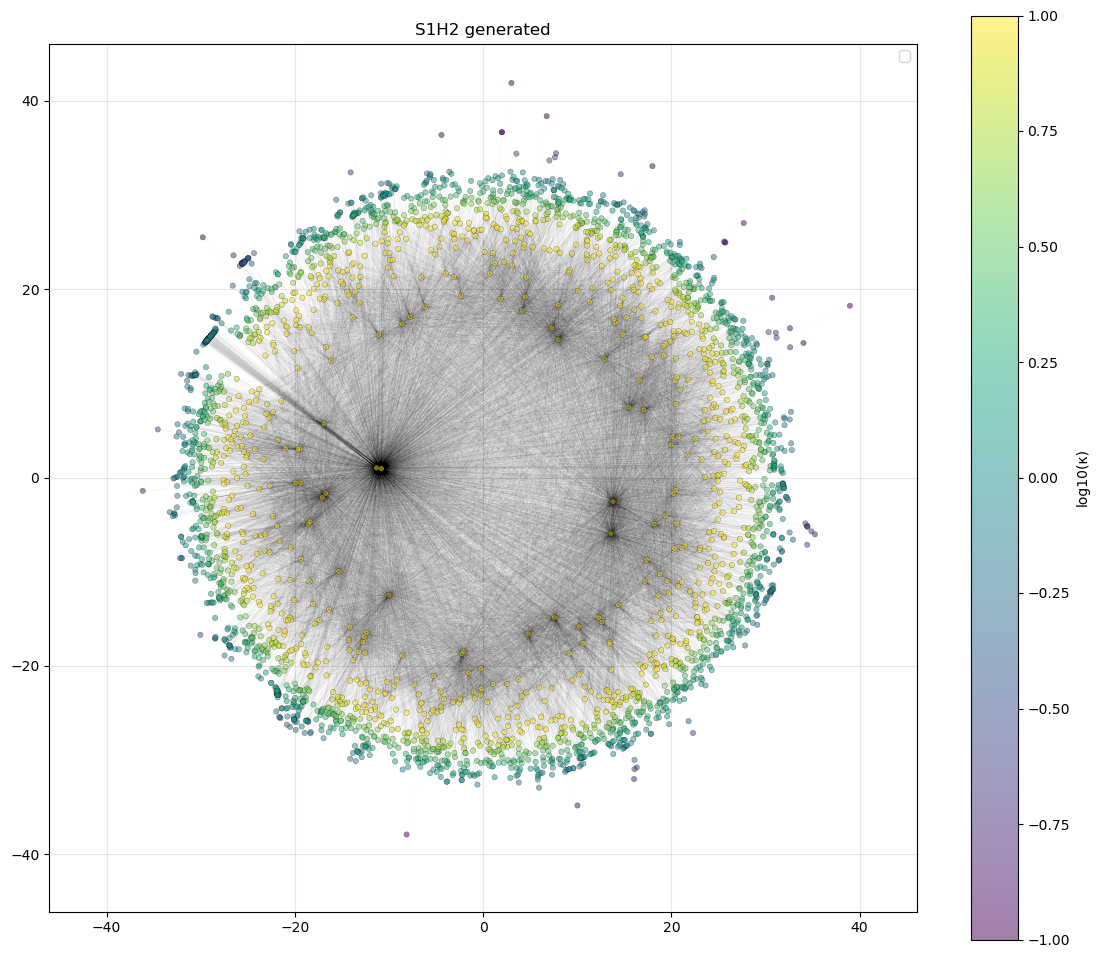

In [31]:
poincare_disc(df, net=G, title='S1H2 generated')

'v996'

/tmp/ipykernel_4588/2594332418.py:174: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


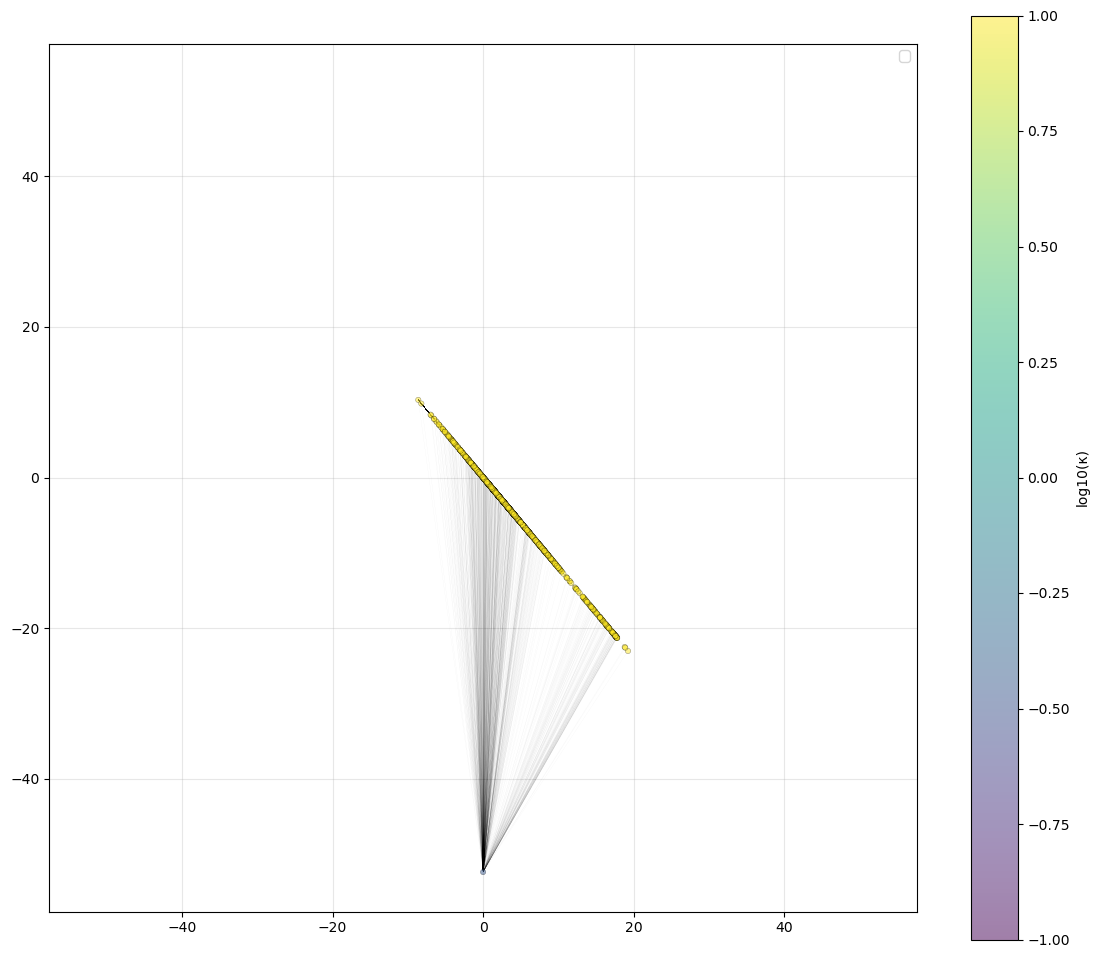

In [11]:
max_key = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
display(max_key)

transformed = lorentz_boost_s1h2(df, max_key, params['kappa_min'])
poincare_disc(transformed, params['kappa_min'], params['nb. vertices'], params['mu'], net=G)

### Epidèmia

In [17]:
! ./tools/epidemics -i 10 -s 8218020 -r 0.1 -m SIR -lt 500 -st -ev -sn 996 -w -o ./pipeline-output-s1h2 ./pipeline-output-s1h2/n3000.edge_weight

 === Configuración de la simulación ===
 Archivo de red: ./pipeline-output-s1h2/n3000.edge_weight
 Nombre de red: n3000
 Modelo: SIR
 Infection rate:    10.000000000000000     
 Recovery rate:   0.10000000000000001     
 Limit time:    500.00000000000000     
 Carpeta de output: ./pipeline-output-s1h2
 Nodo inicial:          996
 Seed:      8218020
 Weighted:  T
 Guardar stats:  T
 Guardar events:  T
 Initialized hash map
 Initialized degrees and pointers
 Initialized neighbour array
 Cleaned neighbours. Reduced neighbours by            0
 --- stats ---
N     =     2994
E     =    33050
<k>   =       22.07748831
<k^2> =     9381.76285905
Var k =       94.30984768
Var w =        0.01798646
Filename will be n3000-wSIR-I=  10.00000-R=   0.10000-S=*****
 Initialized simulation
I/R= 100.00000-S=   8218020-t=start
I/R= 100.00000-S=   8218020-t=dead


In [32]:
events_file = './pipeline-output-s1h2/events-n3000-wSIR-I=  10.00000-R=   0.10000-S=*****.dat'

def skip_comments(line_index, line):
    # Saltar si la línea empieza con '#' o ' #'
    return line.strip().startswith('#') or line.lstrip().startswith('#')

with open(events_file, 'r') as f:
        lines = f.readlines()
    
    # Encontrar la primera línea de datos
first_data_line = 0
for i, line in enumerate(lines):
    if not line.lstrip().startswith('#'):
        first_data_line = i
        break

events = pd.read_csv(events_file, 
                        sep='\\s+', skiprows=first_data_line, names=['t', 'vertex', 'event'])
events['vertex'] = events['vertex'].astype(str)
events


,t,vertex,event
0,0.000000,996,I
1,0.005525,2475,I
2,0.006474,470,I
3,0.007919,162,I
4,0.011190,2241,I
...,...,...,...
5830,71.071965,1749,R
5831,71.613065,2938,R
5832,72.663746,559,R
5833,76.956024,1748,R


In [120]:
df

,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.
0,0,1.844900,1.747890,30.8826
1,1,11.765700,0.307936,27.1770
2,2,103.560000,0.839651,22.8271
3,3,1.527970,2.004090,31.2596
4,4,0.734883,4.082970,32.7235
...,...,...,...,...
2989,2995,31.809900,1.239960,25.1879
2990,2996,13.281600,0.901487,26.9347
2991,2997,19.964700,3.143710,26.1195
2992,2998,6.844630,2.461960,28.2605


In [ ]:
import math
state = {str(v): 'H' for v in df['Vertex']}
epidemics_fig_output = './pipeline-output-s1h2/out'

! rm -r {epidemics_fig_output}
! mkdir {epidemics_fig_output}
i = 0
stop_draw = False
min_time = min(events['t'])
max_time = max(events['t'])
print(f"Time window is {min_time}->{max_time}")
step = 0.1
steps = math.ceil((max_time-min_time)/step)



for i in tqdm(range(steps)):
    t = (i+1)*step+min_time
    t_old = t-step
    ev = events[(events['t'] >= t_old) & (events['t'] < t)]
    for ix, e in ev.iterrows():
        if (e['event'] == 'I'):
            state[e['vertex']] = 'I'
        elif (e['event'] == 'R'):
            state[e['vertex']] = 'R'
        elif (e['event'] == 'E'):
            stop_draw = True
    poincare_epidemic_disc(df, state, f'{epidemics_fig_output}/sim-{i}.png', t)
    i = i+1


df

Time window is 0.0->76.95602404


100%|██████████| 770/770 [03:50<00:00,  3.34it/s]


,Vertex,Inf.Kappa,Inf.Theta,Inf.Hyp.Rad.
0,0,1.844900,1.747890,30.8826
1,1,11.765700,0.307936,27.1770
2,2,103.560000,0.839651,22.8271
3,3,1.527970,2.004090,31.2596
4,4,0.734883,4.082970,32.7235
...,...,...,...,...
2989,2995,31.809900,1.239960,25.1879
2990,2996,13.281600,0.901487,26.9347
2991,2997,19.964700,3.143710,26.1195
2992,2998,6.844630,2.461960,28.2605


In [132]:
x1 = f"{epidemics_fig_output}/sim-%d.png"
x2 = f"{epidemics_fig_output}/../output.gif"
x3 = f"{epidemics_fig_output}/../palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y

ffmpeg version 7.1.2 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Werror=format-security -Wno-error=incompatible-pointer-types -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer ' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-hardened-ld-errors -specs=

In [36]:
events

,t,vertex,event
0,0.000000,996,I
1,0.005525,2475,I
2,0.006474,470,I
3,0.007919,162,I
4,0.011190,2241,I
...,...,...,...
5830,71.071965,1749,R
5831,71.613065,2938,R
5832,72.663746,559,R
5833,76.956024,1748,R



Ejemplo 2: Histogramas para toda la simulación
Generando 78 histogramas...
Progreso: 10/78 histogramas creados


KeyboardInterrupt: 

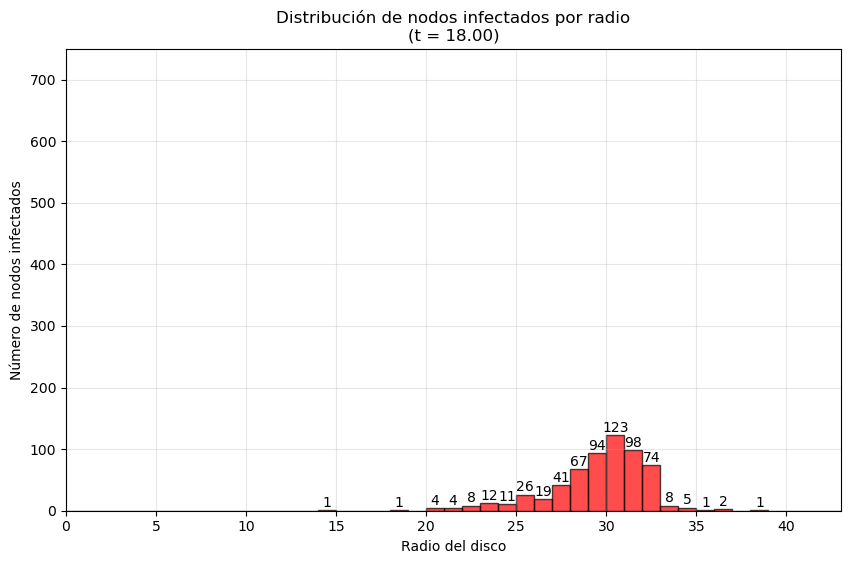

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

def crear_histogramas_infectados_por_radio(df, events, tiempo_objetivo=None, 
                                           bin_size=10, step_tiempo=1, max_infected = None,
                                           output_dir='histogramas'):
    """
    Crea histogramas de nodos infectados agrupados por radio.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columnas 'Vertex' y 'Disc.Radius'
    events : DataFrame
        DataFrame con columnas 't', 'vertex', 'event'
    tiempo_objetivo : float, opcional
        Tiempo específico para generar un solo histograma. Si es None, genera 
        histogramas para toda la simulación
    bin_size : int
        Tamaño de los bins para agrupar los radios
    step_tiempo : float
        Paso de tiempo entre histogramas (si tiempo_objetivo es None)
    output_dir : str
        Directorio donde guardar los histogramas
    """
    
    # Crear directorio de salida si no existe
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Unir la información de los nodos con sus radios
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    if (not max_infected):
        max_infected = len(df)
    max_radius = np.max(df['Disc.Radius'])
    # Función para obtener el estado de los nodos en un tiempo dado
    def get_estado_en_tiempo(t):
        # Filtrar eventos hasta el tiempo t
        events_hasta_t = events[events['t'] <= t].copy()
        
        # Ordenar por tiempo para obtener el último evento de cada nodo
        events_hasta_t = events_hasta_t.sort_values('t')
        
        # Obtener el último estado de cada nodo
        ultimos_eventos = events_hasta_t.groupby('vertex').last()
        
        # Crear diccionario de estados
        estados = {}
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index:
                estados[vertex] = ultimos_eventos.loc[vertex, 'event']
            else:
                estados[vertex] = 'S'  # Por defecto susceptible
        
        return estados
    
    # Función para crear un histograma en un tiempo específico
    def crear_histograma_tiempo(t, ax=None, guardar=True):
        estados = get_estado_en_tiempo(t)
        
        # Clasificar nodos por radio y estado
        radios_infectados = []
        for vertex, estado in estados.items():
            if estado == 'I':  # Solo considerar infectados
                radio = df_radios.get(vertex, 0)
                radios_infectados.append(radio)
        
        # Crear bins
        if radios_infectados:
            max_radio = max(df['Disc.Radius'])
            bins = np.arange(0, max_radio + bin_size, bin_size)
            
            if ax is None:
                fig, ax = plt.subplots(figsize=(10, 6))
            
            # Histograma
            counts, bins, patches = ax.hist(radios_infectados, bins=bins, 
                                           edgecolor='black', alpha=0.7, 
                                           color='red')
            ax.set_xlim(0, max_radius)
            ax.set_ylim(0, max_infected)
            ax.set_xlabel('Radio del disco')
            ax.set_ylabel('Número de nodos infectados')
            ax.set_title(f'Distribución de nodos infectados por radio\n(t = {t:.2f})')
            ax.grid(True, alpha=0.3)
            
            # Añadir etiquetas con los valores
            for i, (count, bin_edge) in enumerate(zip(counts, bins[:-1])):
                if count > 0:
                    ax.text(bin_edge + bin_size/2, count + 0.5, 
                           str(int(count)), ha='center', va='bottom')
            
            if guardar:
                plt.savefig(f'{output_dir}/histograma_t_{t*100}.png', 
                          dpi=300, bbox_inches='tight')
                plt.close()
            else:
                return ax
        else:
            print(f"Advertencia: No hay nodos infectados en t = {t:.2f}")
            return None
    
    # Caso 1: Tiempo específico
    if tiempo_objetivo is not None:
        crear_histograma_tiempo(tiempo_objetivo, guardar=True)
        print(f"Histograma creado para t = {tiempo_objetivo}")
    
    # Caso 2: Toda la simulación con step_tiempo
    else:
        # Encontrar el rango de tiempos
        t_min = events['t'].min()
        t_max = events['t'].max()
        
        # Crear array de tiempos
        tiempos = np.arange(t_min, t_max + step_tiempo, step_tiempo)
        
        print(f"Generando {len(tiempos)} histogramas...")
        for i, t in enumerate(tiempos):
            crear_histograma_tiempo(t, guardar=True)
            if (i + 1) % 10 == 0:
                print(f"Progreso: {i + 1}/{len(tiempos)} histogramas creados")
        
        print(f"¡Completado! Se crearon {len(tiempos)} histogramas en '{output_dir}'")

# Función adicional para crear un histograma combinado
def crear_histograma_combinado(df, events, tiempos_interes, bin_size=10, max_infected=None):
    """
    Crea un histograma combinado con múltiples tiempos en una misma figura.
    """
    df_radios = df.set_index('Vertex')['Disc.Radius'].to_dict()
    
    if (not max_infected):
        max_infected = len(df)
    def get_infectados_por_radio(t):
        events_hasta_t = events[events['t'] <= t].copy()
        events_hasta_t = events_hasta_t.sort_values('t')
        ultimos_eventos = events_hasta_t.groupby('vertex').last()
        
        radios_infectados = []
        for vertex in df['Vertex']:
            if vertex in ultimos_eventos.index and ultimos_eventos.loc[vertex, 'event'] == 'I':
                radios_infectados.append(df_radios.get(vertex, 0))
        
        return radios_infectados
    
    # Crear figura
    fig, axes = plt.subplots(len(tiempos_interes), 1, figsize=(12, 4*len(tiempos_interes)))
    if len(tiempos_interes) == 1:
        axes = [axes]
    
    max_radio = max(df['Disc.Radius'])
    bins = np.arange(0, max_radio + bin_size, bin_size)
    
    for ax, t in zip(axes, tiempos_interes):
        radios = get_infectados_por_radio(t)
        
        if radios:
            ax.set_xlim(0, max_radio)
            ax.set_ylim(0, max_infected)
            ax.hist(radios, bins=bins, edgecolor='black', alpha=0.7, color='red')
            ax.set_xlabel('Radio del disco')
            ax.set_ylabel('Nodos infectados')
            ax.set_title(f't = {t:.2f}')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('histograma_combinado.png', dpi=300, bbox_inches='tight')
    plt.show()


# print("Ejemplo 1: Histograma en t=50")
# crear_histogramas_infectados_por_radio(
#     df, 
#     events, 
#     tiempo_objetivo=10,
#     bin_size=2.5
# )

# # Ejemplo 2: Histogramas para toda la simulación
print("\nEjemplo 2: Histogramas para toda la simulación")
crear_histogramas_infectados_por_radio(
    df, 
    events, 
    step_tiempo=1,  # Cada 20 unidades de tiempo
    bin_size=1,
    output_dir='histogramas_simulacion',
    max_infected=750
)

# # Ejemplo 3: Histograma combinado
# print("\nEjemplo 3: Histograma combinado")
# crear_histograma_combinado(
#     df_ejemplo, 
#     events_ejemplo, 
#     tiempos_interes=[25, 50, 75],
#     bin_size=10
# )

In [45]:
x1 = f"histogramas/histogramas_simulacion/histograma_t_%d.00.png"
x2 = f"histogramas/output.gif"
x3 = f"histogramas/palette.png"

! ffmpeg -i {x1} -vf "palettegen" {x3} -y
! ffmpeg -i {x1} -i {x3} -filter_complex "paletteuse" {x2} -y

ffmpeg version 7.1.2 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Werror=format-security -Wno-error=incompatible-pointer-types -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer ' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-hardened-ld-errors -specs=